In [ ]:
# Dimensionality Reduction
# ================================
# This section performs dimensionality reduction on the standardized SOAP descriptors using PCA, UMAP, or t-SNE.

In [14]:
import os
import json
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


In [15]:
# --- Find the first .npy file in the current directory
npy_file = next(f for f in os.listdir() if f.endswith(".npy"))
all_soap_descriptors = np.load(npy_file)
print(f"Loaded SOAP descriptors from {npy_file}")
print(f"Descriptors shape: {all_soap_descriptors.shape}")

# --- Find the provenance parquet file
parquet_file = next(f for f in os.listdir() if f.endswith(".parquet"))
metadata_df = pd.read_parquet(parquet_file)
print(f"Loaded provenance metadata from {parquet_file}")
print(metadata_df.head())

# --- Find the filemap json
json_file = next(f for f in os.listdir() if f.endswith(".json"))
with open(json_file, "r") as f:
    filemap = json.load(f)
print(f"Loaded filemap from {json_file} to get vasprun.xml paths")


Loaded SOAP descriptors from SOAP_O-C-N_20250916-163203.npy
Descriptors shape: (11171118, 50)
Loaded provenance metadata from SOAP_O-C-N_provenance_20250916-163203.parquet
   file_id  struct_id  atom_id symbol  is_fixed
0        0          0        0      N     False
1        0          0        1      O     False
2        0          0        2      C      True
3        0          0        3      C      True
4        0          0        4      C      True
Loaded filemap from SOAP_O-C-N_filemap_20250916-163203.json to get vasprun.xml paths


In [16]:
# --- Standardize the descriptors
scaler = StandardScaler()
standardized_descriptors = scaler.fit_transform(all_soap_descriptors)
print("Descriptors standardized.")
print(f"Standardized descriptors shape: {standardized_descriptors.shape}")

Descriptors standardized.
Standardized descriptors shape: (11171118, 50)


In [17]:
X = standardized_descriptors

# Choose: "pca", "umap", or "tsne"
method = "pca"          # change as needed
random_state = 42

# Optional: fast pre-reduction for UMAP/t-SNE on large SOAP
pca_prereduce_dim = None   # set None to skip

embedding = None
model = None

if method.lower() == "pca":
    from sklearn.decomposition import PCA
    n_components = 0.95         # embedding dimension
    model = PCA(n_components=n_components, random_state=random_state)
    embedding = model.fit_transform(X)

elif method.lower() == "umap":
    n_components = 10
    try:
        import umap.umap_ as umap
    except ImportError:
        raise RuntimeError("UMAP not installed. pip install umap-learn")

    X_in = X
    if pca_prereduce_dim:
        X_in = PCA(n_components=min(pca_prereduce_dim, X.shape[1]), random_state=random_state).fit_transform(X)

    model = umap.UMAP(
        n_components=n_components,
        n_neighbors=15,        # tune per dataset size
        min_dist=0.0,
        metric="euclidean",
        random_state=random_state,
        verbose=True
    )
    embedding = model.fit_transform(X_in)

elif method.lower() == "tsne":
    n_components = 10 
    from sklearn.manifold import TSNE
    # t-SNE is O(N^2). Use PCA pre-step by default.
    X_in = X
    if pca_prereduce_dim:
        X_in = PCA(n_components=min(pca_prereduce_dim, X.shape[1]), random_state=random_state).fit_transform(X)

    model = TSNE(
        n_components=n_components,
        perplexity=30,         # 5–50 typical
        n_iter=1000,
        learning_rate="auto",
        init="pca",
        random_state=random_state,
        verbose=1,
        method="barnes_hut" if X_in.shape[0] < 50000 else "exact"
    )
    embedding = model.fit_transform(X_in)

else:
    raise ValueError("method must be 'pca', 'umap', or 'tsne'")

print(f"{method.upper()} embedding shape:", embedding.shape)

/Users/samuel/Desktop/postdoc_PhLAM/codes/data_sampling/.venv/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/samuel/Desktop/postdoc_PhLAM/codes/data_sampling/.venv/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/samuel/Desktop/postdoc_PhLAM/codes/data_sampling/.venv/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X


PCA embedding shape: (11171118, 4)


/Users/samuel/Desktop/postdoc_PhLAM/codes/data_sampling/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/samuel/Desktop/postdoc_PhLAM/codes/data_sampling/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/samuel/Desktop/postdoc_PhLAM/codes/data_sampling/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


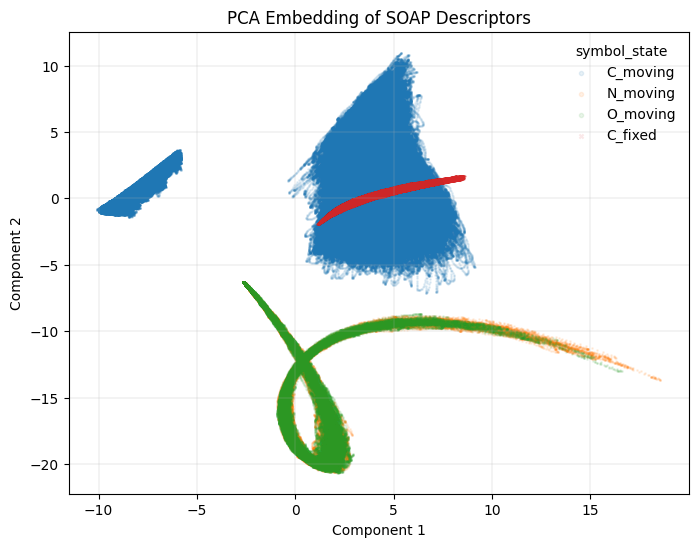

In [22]:
# require both columns
for col in ("symbol", "is_fixed"):
    if col not in metadata_df.columns:
        raise KeyError(f"Provenance parquet must contain '{col}' column.")

symbols = metadata_df["symbol"].astype(str)
states  = np.where(metadata_df["is_fixed"].to_numpy(), "fixed", "moving")
labels_combined = (symbols + "_" + states).astype("category")
cats = list(labels_combined.cat.categories)
codes = labels_combined.cat.codes.to_numpy()  # 0..K-1

plt.figure(figsize=(8, 6))
if embedding.shape[1] >= 2:
    # split labels: moving first, fixed last
    ordered_cats = [lab for lab in cats if lab.endswith("_moving")] + \
                   [lab for lab in cats if lab.endswith("_fixed")]

    for lab in ordered_cats:
        idx = (labels_combined == lab)
        if not np.any(idx):
            continue
        marker = "x" if lab.endswith("_fixed") else "o"
        plt.scatter(embedding[idx, 0], embedding[idx, 1],
                    s=1, alpha=0.1, marker=marker, label=lab)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.title(f"{method.upper()} Embedding of SOAP Descriptors")
    plt.grid(True, linewidth=0.2)
    plt.legend(markerscale=3, frameon=False, loc="best", title="symbol_state")
    plt.show()

In [30]:
from dim_red_utils import select_by_pca_box, origins_from_mask, group_summary

# Example usage
box = {0: (10, 15), 1: (-15, -5)}
# box is your PCA region, e.g. {0:(-5,-2), 1:(1,3)}
mask = select_by_pca_box(embedding, box)

# Resolve provenance for selected points
sel = origins_from_mask(mask, metadata_df, filemap)

# Keep exactly what you need (+ optional index in embedding)
sel_min = sel.loc[:, ["file_path", "struct_id", "atom_id"]].copy()
sel_min["row_index"] = np.nonzero(mask)[0]  # optional: row position in embedding/descriptors

print(f"Selected atoms: {len(sel_min)}")
print(sel_min.head())

# Save if needed
sel_min.to_csv("pca_selection_struct_file_atom.csv", index=False)

Selected atoms: 2643
                                                file_path  struct_id  atom_id  \
147588  /Volumes/LaCie/postdoc_PhLAM/NO_HOPG/data/aimd...       1506        0   
147686  /Volumes/LaCie/postdoc_PhLAM/NO_HOPG/data/aimd...       1507        0   
283710  /Volumes/LaCie/postdoc_PhLAM/NO_HOPG/data/aimd...       1387        0   
283808  /Volumes/LaCie/postdoc_PhLAM/NO_HOPG/data/aimd...       1388        0   
283906  /Volumes/LaCie/postdoc_PhLAM/NO_HOPG/data/aimd...       1389        0   

        row_index  
147588     147588  
147686     147686  
283710     283710  
283808     283808  
283906     283906  
